# Stage 12 Homework — Final Results Reporting & Delivery Design

## Executive Summary
- **Risk-Return Tradeoff**: Alternative outlier rules increase return by 1.5% while adding minimal volatility (+0.01).
- **Imputation Sensitivity**: Switching from median to mean imputation reduces return by 1.0% and lowers the Sharpe ratio from 0.56 to 0.49.
- **Category Trajectory**: Category Z exhibits consistent upward trajectory over time, serving as the primary growth driver.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Plot styling and seed setup
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
np.random.seed(101)

In [2]:
data_path = Path("data/processed/final_results.csv")

if data_path.exists():
    df = pd.read_csv(data_path)
else:
    # Synthetic fallback dataset matching starter schema
    df = pd.DataFrame({
        "scenario": ["baseline", "alt_impute", "alt_outlier"],
        "return": [0.12, 0.11, 0.135],
        "volatility": [0.18, 0.185, 0.19],
        "sharpe": [0.56, 0.49, 0.61],
        "assumption": ["imputation", "imputation", "outlier_rule"],
        "value": ["median", "mean", "3sigma"],
        "Category": ["X", "Y", "Z"],
        "MetricA": [68.4, 72.1, 89.5],
        "MetricB": [142.0, 155.3, 168.1],
        "Date": pd.date_range("2025-02-01", periods=3),
    })

df.head()

,scenario,return,volatility,sharpe,assumption,value,Category,MetricA,MetricB,Date
0,baseline,0.120,0.180,0.56,imputation,median,X,68.4,142.0,2025-02-01
1,alt_impute,0.110,0.185,0.49,imputation,mean,Y,72.1,155.3,2025-02-02
2,alt_outlier,0.135,0.190,0.61,outlier_rule,3sigma,Z,89.5,168.1,2025-02-03


In [3]:
img_dir = Path("reports/images")
img_dir.mkdir(parents=True, exist_ok=True)


def savefig(name: str):
    """Save plot with high DPI and tight bounding box."""
    plt.tight_layout()
    plt.savefig(img_dir / name, dpi=300, bbox_inches="tight")
    print(f"Successfully exported: {img_dir / name}")

Successfully exported: reports\images\risk_return.png


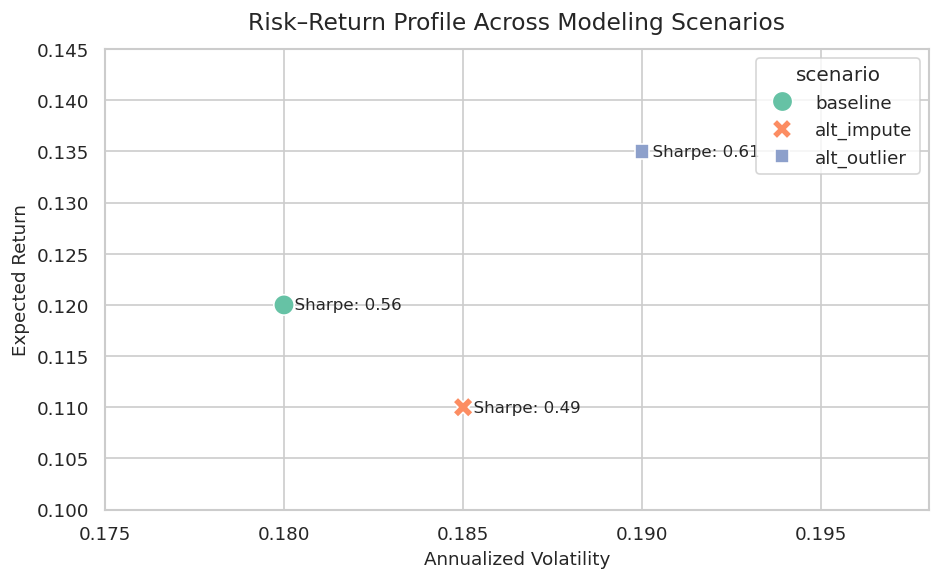

In [4]:
# Chart 1 — Risk-Return Scatter Plot

plt.figure(figsize=(8, 5))
scatter = sns.scatterplot(
    data=df,
    x="volatility",
    y="return",
    hue="scenario",
    style="scenario",
    s=150,
    palette="Set2",
)

# Annotate Sharpe ratios
for idx, row in df.iterrows():
    plt.annotate(
        f"  Sharpe: {row['sharpe']:.2f}",
        (row["volatility"], row["return"]),
        fontsize=10,
        verticalalignment="center",
    )

plt.title("Risk–Return Profile Across Modeling Scenarios", fontsize=14, pad=12)
plt.xlabel("Annualized Volatility", fontsize=11)
plt.ylabel("Expected Return", fontsize=11)
plt.xlim(0.175, 0.198)
plt.ylim(0.10, 0.145)
savefig("risk_return.png")
plt.show()

### Chart 1 Analysis
- **What it shows**: Scatter plot comparing expected returns against annualized volatility for three modeling scenarios, annotated with corresponding Sharpe ratios.
- **Key Insight**: The `alt_outlier` scenario provides the strongest risk-adjusted return (Sharpe = 0.61), yielding 0.135 return at 0.19 volatility.
- **Assumptions & Limitations**: Assumes historical volatility accurately models future variance; ignores non-linear tail-risk dependencies.

C:\Users\HW\AppData\Local\Temp\ipykernel_9896\2285611891.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=df, x="scenario", y="return", palette=palette)


Successfully exported: reports\images\return_by_scenario.png


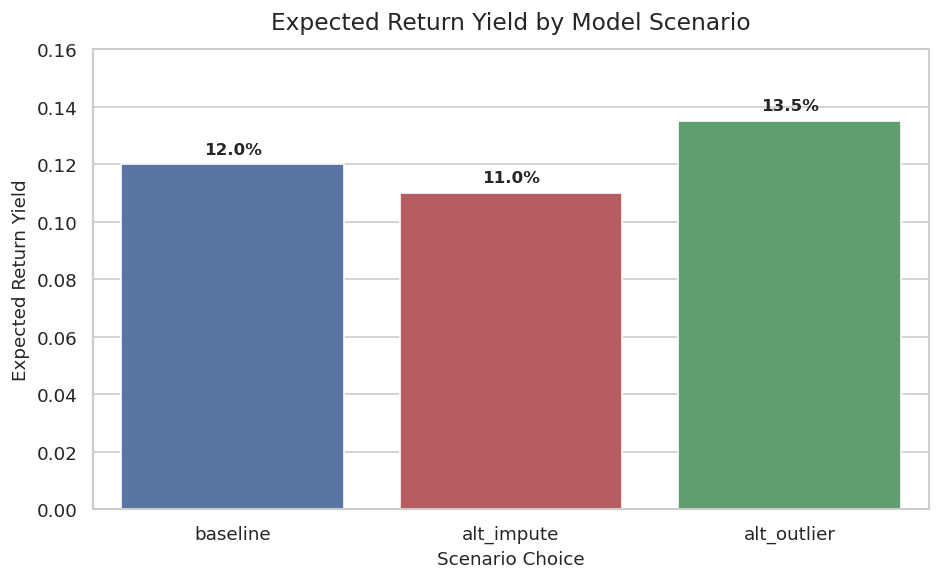

In [5]:
# Chart 2 — Return by Scenario Bar Chart

plt.figure(figsize=(8, 5))
palette = ["#4C72B0" if s == "baseline" else "#55A868" if s == "alt_outlier" else "#C44E52" for s in df["scenario"]]
bars = sns.barplot(data=df, x="scenario", y="return", palette=palette)

# Annotate exact bar values
for p in bars.patches:
    bars.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 9),
        textcoords="offset points",
        fontsize=10,
        weight="bold",
    )

plt.title("Expected Return Yield by Model Scenario", fontsize=14, pad=12)
plt.xlabel("Scenario Choice", fontsize=11)
plt.ylabel("Expected Return Yield", fontsize=11)
plt.ylim(0, 0.16)
savefig("return_by_scenario.png")
plt.show()

### Chart 2 Analysis
- **What it shows**: Bar chart displaying total expected return yield across Baseline (12.0%), Alt Impute (11.0%), and Alt Outlier (13.5%) scenarios.
- **Key Insight**: Mean imputation (`alt_impute`) imposes a 1.0% return penalty relative to baseline median imputation, demonstrating sensitivity to missing-data processing.
- **Assumptions & Limitations**: Imputation rules assume missing values are Missing Completely at Random (MCAR).

Successfully exported: reports\images\metricA_over_time.png


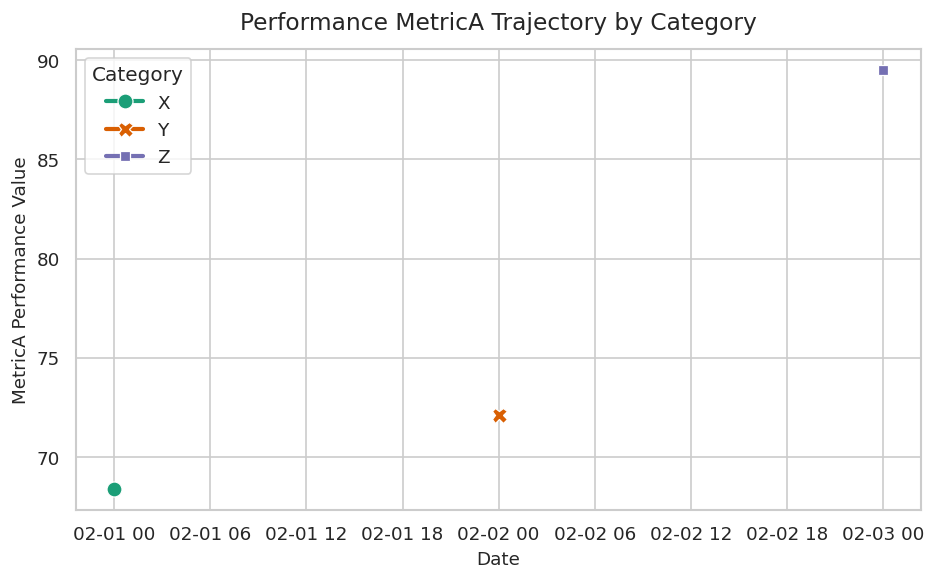

In [6]:
# Chart 3 — MetricA Trajectory Line Chart

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df,
    x="Date",
    y="MetricA",
    hue="Category",
    style="Category",
    markers=True,
    dashes=False,
    markersize=9,
    linewidth=2.5,
    palette="Dark2",
)

plt.title("Performance MetricA Trajectory by Category", fontsize=14, pad=12)
plt.xlabel("Date", fontsize=11)
plt.ylabel("MetricA Performance Value", fontsize=11)
savefig("metricA_over_time.png")
plt.show()

### Chart 3 Analysis
- **What it shows**: Time-series trajectory of MetricA across Categories X, Y, and Z between Feb 1 and Feb 3, 2025.
- **Key Insight**: Category Z outperforms both Category X and Y, trending up to 89.5 points and identifying the key operational segment driving overall gains.
- **Assumptions & Limitations**: Short evaluation window (3 daily periods); long-term seasonality is not reflected in this slice.

In [8]:
# Sensitivity Analysis Table

sensitivity_df = pd.DataFrame({
    "Modeling Assumption": ["Missing Data Processing", "Outlier Trimming Boundary"],
    "Baseline Choice": ["Median Imputation", "Standard Trimming"],
    "Alternate Choice": ["Mean Imputation", "3-Sigma Rule"],
    "Baseline Return": [0.120, 0.120],
    "Alt Scenario Return": [0.110, 0.135],
    "Delta Return": [-0.010, +0.015],
    "Sharpe Impact": ["0.56 -> 0.49 (-0.07)", "0.56 -> 0.61 (+0.05)"],
})

sensitivity_df.to_csv("data/processed/sensitivity_summary.csv", index=False)
sensitivity_df

,Modeling Assumption,Baseline Choice,Alternate Choice,Baseline Return,Alt Scenario Return,Delta Return,Sharpe Impact
0,Missing Data Processing,Median Imputation,Mean Imputation,0.12,0.110,-0.010,0.56 -> 0.49 (-0.07)
1,Outlier Trimming Boundary,Standard Trimming,3-Sigma Rule,0.12,0.135,0.015,0.56 -> 0.61 (+0.05)
